<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_2/Group_Exercise_2_PART_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 2- Group Exercise 2 - Regression Analysis and Feature Selection**

**Group Exercise 2**

Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset "House Prices - Advanced Regression Techniques"

The dataset contains properties with various environmental variables.

Source:

https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques

# **Step 0:- (Importing desired Libraries)**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# **1. Preprocessing.**

# **Step 1.1:-**
Handling the missing values.

In [53]:
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train_house.csv') # RAW Data from GitHub
#house_data.head()
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (1460, 81)

Missing values:
PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


# Displaying numerical and categorical columns:-

In [54]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:- \n")
print(numerical_columns)
print("\nCategorical columns:-\n")
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Numerical Columns:- 

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

Categorical columns:-

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'Bsmt

# ***Step 1:-***

# **1.1. Handling Missing Values**
Identify missing values

Apply appropriate imputation methods (mean, median, mode, or justified alternative)

In [55]:
from pandas.core.arrays import categorical
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns
# numerical imputation
imput_median = SimpleImputer(strategy="median")
imput_mean = SimpleImputer(strategy="mean")

for feature in numerical_columns:

  if df[feature].isnull().sum().mean() == 0:  # if none are missing
    continue                                  # continue in the loop

  print(f"Numerical Feature {feature} missing: {df[feature].isnull().sum()}")
  if df[feature].skew() > 1 or df[feature].skew() < -1:
    # imput_median
    df[[feature]] = imput_median.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_median.strategy}")
  else:
    # imput_mean
    df[[feature]] = imput_mean.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_mean.strategy}")


# categorical imputation
imputer_mode = SimpleImputer(strategy="most_frequent")

for feature in categorical_columns:
  if df[feature].isnull().sum() == 0:
    continue

  print(f"Categorical Feature {feature} missing: {df[feature].isnull().sum()}")
  df[[feature]] = imputer_mode.fit_transform(df[[feature]])
  print(f"Categorical Feature {feature} imputed {imputer_mode.strategy}")

# Adjusted features
print("\nAdjusted features:")
print(df.isnull().sum().sort_values(ascending=False))


Numerical Feature LotFrontage missing: 259
Numerical Feature LotFrontage imputed median
Numerical Feature MasVnrArea missing: 8
Numerical Feature MasVnrArea imputed median
Numerical Feature GarageYrBlt missing: 81
Numerical Feature GarageYrBlt imputed mean
Categorical Feature Alley missing: 1369
Categorical Feature Alley imputed most_frequent
Categorical Feature MasVnrType missing: 872
Categorical Feature MasVnrType imputed most_frequent
Categorical Feature BsmtQual missing: 37
Categorical Feature BsmtQual imputed most_frequent
Categorical Feature BsmtCond missing: 37
Categorical Feature BsmtCond imputed most_frequent
Categorical Feature BsmtExposure missing: 38
Categorical Feature BsmtExposure imputed most_frequent
Categorical Feature BsmtFinType1 missing: 37
Categorical Feature BsmtFinType1 imputed most_frequent
Categorical Feature BsmtFinType2 missing: 38
Categorical Feature BsmtFinType2 imputed most_frequent
Categorical Feature Electrical missing: 1
Categorical Feature Electrical i

Explanation:

Mean is the better choice for symmetrical distributions, whereas median should be chosen for distributions with outliers and skewness. The categories are determined based on frequency.

# **1.2. Handling Outliers**
Detect outliers using Z-score

Handle them via removal or transformation


**A visual representation before outlier handling:-**

---





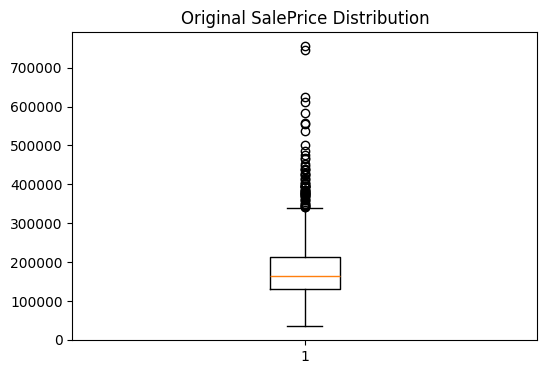

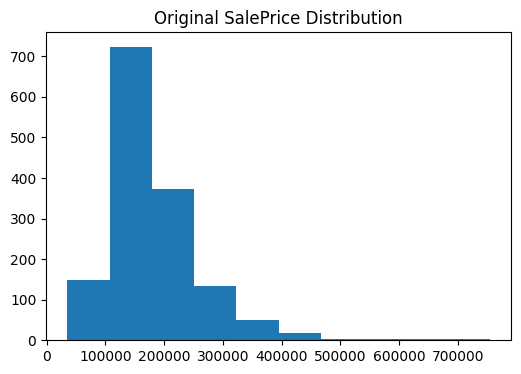

In [56]:
plt.figure(figsize=(6,4))
plt.boxplot(df['SalePrice'])
plt.title("Original SalePrice Distribution")
plt.show()
plt.figure(figsize=(6,4))
plt.hist(df['SalePrice'])
plt.title("Original SalePrice Distribution")
plt.show()

**Handling Outliers:-**

---



In [57]:
df['SalePrice_z_score'] = zscore(df['SalePrice'])

outliers = df[np.abs(df['SalePrice_z_score']) > 3]

print("Outliers:", len(outliers))

Outliers: 22


**We have 22 outliers here.**
# **TREATMENTS:-**

Deleted outliers: 22


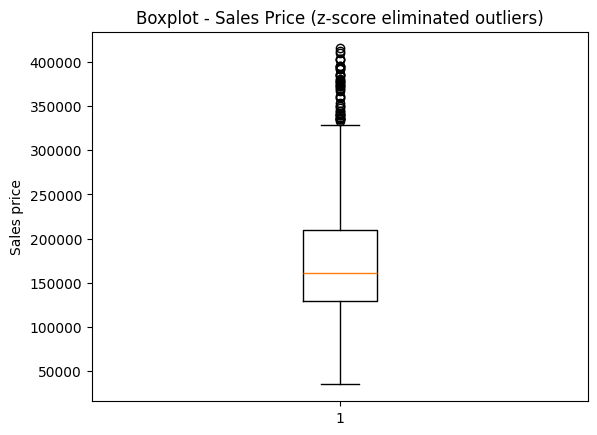

In [58]:
# Delete outliers using z-score

threshold = 3 # Outliers (> 99,7% der normal distribution)

df_no_outliers = df[np.abs(df['SalePrice_z_score']) <= threshold]

print("Deleted outliers:", len(df) - len(df_no_outliers))
plt.boxplot(df_no_outliers['SalePrice'])
plt.title('Boxplot - Sales Price (z-score eliminated outliers)')
plt.ylabel('Sales price')
plt.show()


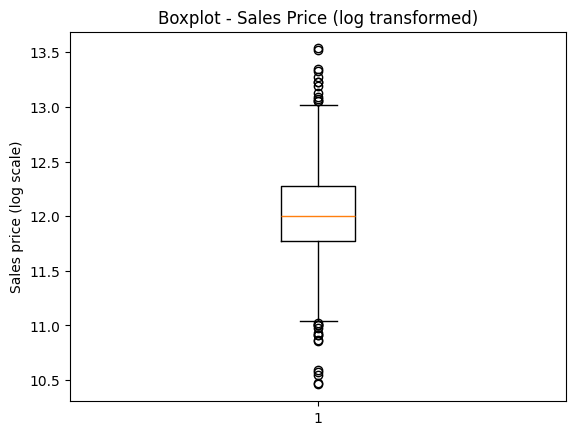

In [59]:
# Reduce outliers using log1p transformation

df['SalePrice_log_transform'] = np.log1p(df['SalePrice'])

plt.boxplot(df['SalePrice_log_transform'])
plt.title('Boxplot - Sales Price (log transformed)')
plt.ylabel('Sales price (log scale)')
plt.show()

Conclusion:

Eliminating outliers using Z-scores is not necessarily useful here, as the authenticity of the core data is not preserved and extreme outliers are eliminated. For example, luxury properties may be just as relevant to the price structure of other properties. Log transformation is the better choice here.

**A visual representation after outlier handling:-**

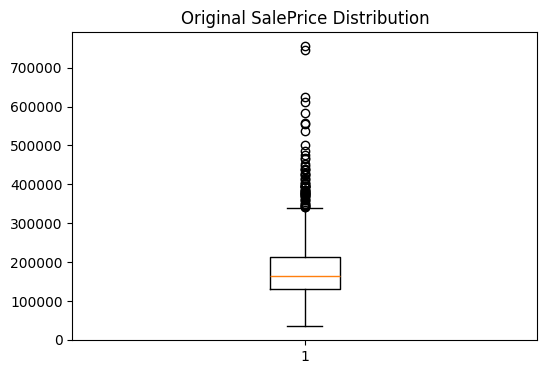

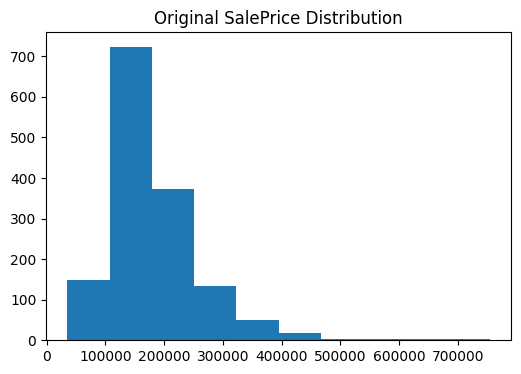

In [60]:
plt.figure(figsize=(6,4))
plt.boxplot(df['SalePrice'])
plt.title("Original SalePrice Distribution")
plt.show()
plt.figure(figsize=(6,4))
plt.hist(df['SalePrice'])
plt.title("Original SalePrice Distribution")
plt.show()

# **2. Scaling Numerical Features**
Apply Z-score standardization

Apply Min–Max normalization


In [61]:
features = ['YearBuilt', 'SalePrice']
X = df[features].copy()

# Standardisation Z-Score
z_scaler = StandardScaler()
z_X = z_scaler.fit_transform(X)
z_X = pd.DataFrame(z_X, columns=[f + '_z' for f in features])

# Normalisation (Min Max)
mm_scaler = MinMaxScaler()
mm_X = mm_scaler.fit_transform(X)
mm_X = pd.DataFrame(mm_X, columns=[f + '_mm' for f in features])

# compared
comparsion = pd.concat([X, z_X, mm_X], axis=1)
print(comparsion.head())

   YearBuilt  SalePrice  YearBuilt_z  SalePrice_z  YearBuilt_mm  SalePrice_mm
0       2003     208500     1.050994     0.347273      0.949275      0.241078
1       1976     181500     0.156734     0.007288      0.753623      0.203583
2       2001     223500     0.984752     0.536154      0.934783      0.261908
3       1915     140000    -1.863632    -0.515281      0.311594      0.145952
4       2000     250000     0.951632     0.869843      0.927536      0.298709


Explanation

Z-score is preferable when data is approximately symmetrical/normally distributed. Each variable is given equal weighting. The Z-score is better suited to dealing with outliers. Min-max scaling, on the other hand, is useful when dealing with limited ranges, e.g. 0–1, i.e. features are required within strict limits.

# **3. Feature Selection**


In [62]:
# Ensuring that there are no missing values
#print(df.isnull().sum().sort_values(ascending=False))

X = df[['YearBuilt', 'LotArea']]          # influencing factors (if necessary further scaling required)
y = df['SalePrice']                       # target value

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X, y)

pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})  #  If coefficient is higher, feature increases price

,Feature,Coefficient
0,YearBuilt,1365.776044
1,LotArea,2.041172


**Version 2: Lasso optimised with more influencing factors, scaler and training**

In [63]:
# Ensuring that there are no missing values
#print(df.isnull().sum().sort_values(ascending=False))

# Feature grouping (splitting)
numerical_cols = ['YearBuilt', 'LotArea', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']
categorical_cols = ['Neighborhood']

X = df[numerical_cols + categorical_cols]                                         # influencing factors (if necessary further scaling required)
y = df['SalePrice']                                                               # target value

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   # 80% Trainingset and 20% Testset

# One-Hot-Encoder (Categorical cols), StandardScaler
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),                                # Scaling mean close to 0 and standard deviation close to 1
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)         # One-Hot-Encoder on 'Neighborhood'
    ])


# Process pipeline (Preparation --> Lasso)
model = Pipeline(steps=[
  ('preprocess', preprocess),
  ('lasso', Lasso(alpha=0.01, max_iter=50000, tol=0.01, random_state=42))         # Alpha: small (a large alpha would pull the coefficients more strongly towards 0)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: The model is on average approx {rmse:.0f} beside.")

# Get training data (Lasso)
lasso = model.named_steps['lasso']

# Get preprocessor
ctg = model.named_steps['preprocess']

# Pick up features and merge
num_cols = numerical_cols
ohe_cat = ctg.named_transformers_['cat']
cat_cols = ohe_cat.get_feature_names_out(categorical_cols)        # DICT: Returns the new column names from Transformer

features = np.concatenate([num_cols, cat_cols])                   # Merge list

# DF coefficient
coefs = lasso.coef_                                               # Coefficients from Lasso model
coef_df = pd.DataFrame({                                          # DataFrame with two columns
    'Feature': features,
    'Coefficient': coefs
})

# Sorting (by importance)
coef_df['AbsCoeff'] = coef_df['Coefficient'].abs()                # Amount of the coefficients
coef_df = coef_df.sort_values(by='AbsCoeff', ascending=False)
print("\nCoefficient:")
print(coef_df.head(15))

RMSE: The model is on average approx 37398 beside.

Coefficient:
                 Feature   Coefficient      AbsCoeff
28  Neighborhood_StoneBr  54907.618863  54907.618863
22  Neighborhood_NridgHt  49937.923937  49937.923937
21  Neighborhood_NoRidge  46725.337831  46725.337831
30  Neighborhood_Veenker  41506.555890  41506.555890
7   Neighborhood_Blueste -37844.444221  37844.444221
8    Neighborhood_BrDale -37475.084536  37475.084536
12  Neighborhood_Crawfor  28005.777728  28005.777728
3              GrLivArea  24604.668117  24604.668117
2            OverallQual  24179.516120  24179.516120
19  Neighborhood_NPkVill -17898.103064  17898.103064
10  Neighborhood_ClearCr  16517.639900  16517.639900
6   Neighborhood_Blmngtn -14932.883554  14932.883554
16  Neighborhood_MeadowV -13941.081234  13941.081234
14  Neighborhood_Gilbert -12386.151299  12386.151299
0              YearBuilt  12225.837571  12225.837571


**Note: Coefficient indicates the direction and strength of influence, while AbsCoeff focuses only on the strength or importance of influence.**

**Visual weighting of features**

---



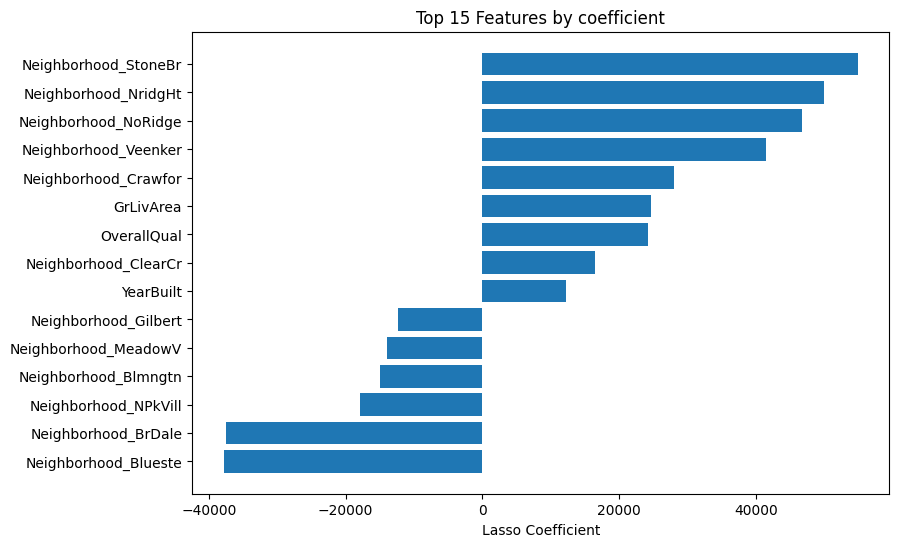

In [64]:

top_n = 15
plot_df = coef_df.head(top_n).sort_values('Coefficient')
plt.figure(figsize=(9,6))
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.xlabel('Lasso Coefficient')
plt.title(f'Top {top_n} Features by coefficient')
plt.show()

Explanation:

Models such as Lasso are sensitive to the magnitude of features (features with high values in the context of features with low values). The aim of scaling is to make the features more comparable. The coefficient indicates how a feature affects the price.

Lasso evaluates influence in the model.

#Build and Evaluate Models

1.Train a Linear Regression model.

2.Evaluate using R² Score and RMSE.

3.Perform K-Fold Cross-Validation (e.g., 5-fold).

In [65]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Feature grouping (splitting)
numerical_cols = ['YearBuilt', 'LotArea', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']
categorical_cols = ['Neighborhood']

X = df[numerical_cols + categorical_cols]                                         # influencing factors (if necessary further scaling required)
y = df['SalePrice']                                                               # target value

# Train-Test-Splitt
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)                                                                                 # 80% Trainingset and 20% Testset

# One-Hot-Encoder (Categorical cols), StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),                                   # Scaling mean close to 0 and standard deviation close to 1
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)         # One-Hot-Encoder on 'Neighborhood'
    ])

# Process pipeline (Preparation + Lineare Regression)
model = Pipeline(steps=[
  ('preprocess', preprocessor),
  ('linreg', LinearRegression())
])

# TRAINING: Model training
model.fit(X_train, y_train)

# EVALUATION TRAIN AND TEST DATA ON OVERFITTING
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

# Roor Mean Squared Error (forecast quality)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_predict))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_predict))


# R2 (Explanatory power of features)
r2_train = r2_score(y_train, y_train_predict)
r2_test = r2_score(y_test, y_test_predict)

print(f"Train RMSE: {rmse_train:,.0f}")
print(f"Test RMSE: {rmse_test:,.0f}")
print(f"Train R2: {r2_train:.2f}")
print(f"Test R2: {r2_test:.2f}")

# K-Fold Cross-Validation 5-fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# R2 mittels Cross-Validation
cv_r2 = cross_val_score(model, X, y, cv=kfold, scoring='r2')

# RMSE mittels Cross-Validation
cv_mse = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_mse)

print("\n5-fold Cross-Validation:")
print("\nCV-R2 per fold:          ", np.round(cv_r2, 3))
print("\n--> Average CV-R2:       ", cv_r2.mean().round(3), "<--")
print("\nCV-RMSE per fold:        ", np.round(cv_rmse, 0))
print("\n--> Average CV-RMSE:     ", np.round(cv_rmse.mean(), 0), "<--")



Train RMSE: 34,525
Test RMSE: 37,546
Train R2: 0.80
Test R2: 0.82

5-fold Cross-Validation:

CV-R2 per fold:           [0.816 0.821 0.59  0.809 0.839]

--> Average CV-R2:        0.775 <--

CV-RMSE per fold:         [37546. 34916. 47608. 34587. 28998.]

--> Average CV-RMSE:      36731.0 <--


RMSE indicates that this model is off by an average of approximately 37,546 monetary units.

R2 indicates that 82% of the variance in price (the dependent variable) is explained. More precisely:


*   Property prices fluctuate in the dataset (variance)
*   The model used can explain 82% of these fluctuations using the features.
*   18% are unexplained, i.e. errors, random values or missing features. E.g. Is there a special swimming pool, school quality in the region, level of education...

CV-R2, on the other hand, indicates that with **77.5% variance across different training-test splits**, the model generalises stably.

CV-RMSE indicates that the model has a deviation of 36,731 monetary units - **across multiple splits**.

#Enhance the Model
1.Experiment with feature selection techniques and analyze their impact.

2.Visualize results (e.g., feature importance, residual plots).

,Model,CV_r2_mean,CV_r2_std,CV_RMSE_mean,CV_RMSE_std
2,GradientBoosting,0.837926,0.046667,0.158232,0.018251
1,RandomForest,0.825795,0.048097,0.164239,0.018012
0,ElasticNet,0.816810,0.069244,0.166960,0.023870


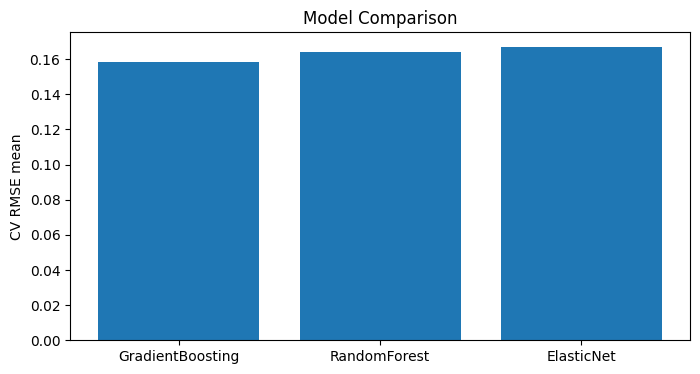


Best model: GradientBoosting


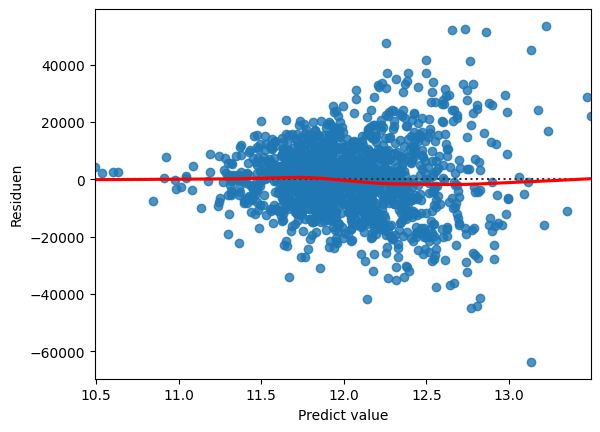

In [78]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
import seaborn as sns

# Correcting skewness
y_model = np.log1p(y)

# Ensure encoding of the text/categorical columns in this section
categorical_columns = X.select_dtypes(include=["object", "category"]).columns
numerical_columns = X.select_dtypes(exclude=["object", "category"]).columns

# Perform median imputation in this section; StandardScaler primarily for ElasticNet
# Reason: Features must be treated equally (surfaces, rooms, etc.) -> coefficient weighting
# RandomForest and GradientBoosting "split" and "set in series" -> no effect using Scaler
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),   # missing with most frequent value
    ("ohnehot", OneHotEncoder(handle_unknown="ignore"))     # 0/1 /// ignore (validation/training fold)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

# omparison of feature selection during training using three embedded methods
models = {
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,     # 500 trees (acceptable speed in the colab standard test)
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1             # all CPU-Cores
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=1000,    # 1000 Bäume und kleine Laerning-Rate
        learning_rate=0.05,   # < 1: Aiming for improved generalisation
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

# K-Fold Cross-Validation 5-fold
cv = KFold(n_splits=5, shuffle=True, random_state = 42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

results = []

for designation, model in models.items():
  pipeline = Pipeline(steps=[
      ("prep", preprocessor),
      ("model", model)
  ])

  # Trains and evaluates pipeline in 5 folds
  cv_res = cross_validate(
      pipeline,
      X,
      y_model,
      cv=cv,
      scoring=scoring,
      return_train_score = False
  )

  mean_r2 = np.mean(cv_res["test_r2"])
  std_r2 = np.std(cv_res["test_r2"])
  mean_rmse = -np.mean(cv_res["test_rmse"])
  std_rmse = np.std(-cv_res["test_rmse"])

  results.append({
      "Model": designation,
      "CV_r2_mean": mean_r2,
      "CV_r2_std": std_r2,
      "CV_RMSE_mean": mean_rmse,
      "CV_RMSE_std": std_rmse
  })

results_to_df = pd.DataFrame(results).sort_values(by="CV_RMSE_mean")
display(results_to_df)

# diagram
plt.figure(figsize=(8, 4))
plt.bar(results_to_df["Model"], results_to_df["CV_RMSE_mean"])
plt.ylabel("CV RMSE mean")
plt.title("Model Comparison")
plt.show()

# Best model selection (iloc -> first line from the sorted list)
print("\nBest model:", results_to_df.iloc[0]["Model"])

best_model = models[results_to_df.iloc[0]["Model"]]

# Object (pipeline) for fit and predict
best_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X, y_model)

pred = best_pipeline.predict(X)

# Both sizes must be brought into the same space: value back to original space
residuals = np.expm1(y_model) - np.expm1(pred)

sns.residplot(x=pred, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Predict value")
plt.ylabel("Residuen")
plt.show()



Gradient boosting achieved the best prediction values, confirming this with an average CV-R2 of 0.83 and a parallel RMSE of 0.1578. Nevertheless, all methods are at a similarly high level.